In [2]:
import torch

def pendulum_dynamics_without_u(t, state, u_func, beta=0.4, omega_0=9.81/2, K=15):
    theta = state[:, 0:1]
    omega = state[:, 1:2]

    domega_dt = -2*beta*omega - omega_0**2 * torch.sin(theta) + K * u_func(t)
    dtheta_dt = omega

    return torch.cat([dtheta_dt, domega_dt], dim=1)

def u_func_template(t, steering_table, num_steps, dt):
    idx = int(t.item() / dt) 
    idx = min(idx, num_steps - 1)
    idx = max(idx, 0)
    return steering_table[idx]

Train shape: torch.Size([160, 8, 2])
Val shape: torch.Size([160, 3, 2])


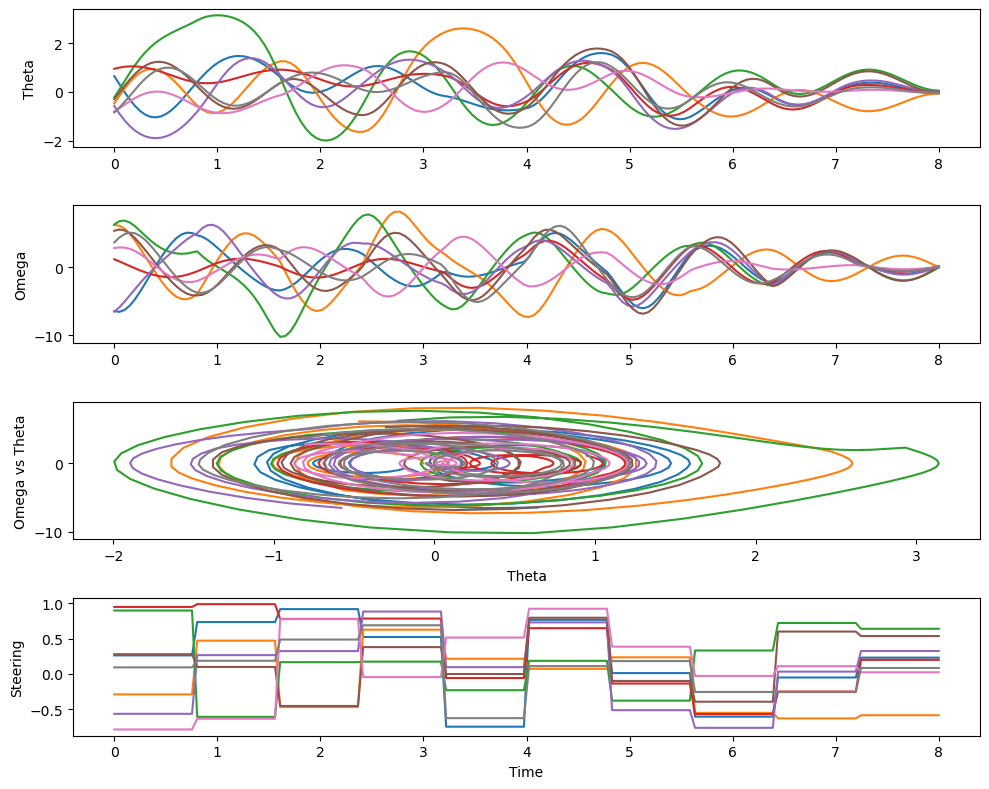

In [ ]:
from torchdiffeq import odeint
from matplotlib import pyplot as plt
torch.manual_seed(42)


NUM_TRAJECTORIES = 8
NUM_TRAJECTORIES_VAL = 3
T = 8
CHUNK_LEN = 2
dt = 0.05
NUM_STEERING_JUMP = 10
STABILITY_THRESHOLD = 0.1
TOTAL_STEPS = int(T / dt) 
max_theta0 = 0.8*torch.pi
steps_per_jump = TOTAL_STEPS // NUM_STEERING_JUMP

steering_table = (torch.rand((NUM_STEERING_JUMP, NUM_TRAJECTORIES, 1)) * 2 - 1).repeat_interleave(steps_per_jump, dim=0)
steering_table_val = (torch.rand((NUM_STEERING_JUMP, NUM_TRAJECTORIES_VAL, 1)) * 2 - 1).repeat_interleave(steps_per_jump, dim=0)
u_func = lambda t: u_func_template(t, steering_table=steering_table, num_steps=TOTAL_STEPS, dt=dt)
u_func_val = lambda t: u_func_template(t, steering_table=steering_table_val, num_steps=TOTAL_STEPS, dt=dt)

y_0s = torch.rand((NUM_TRAJECTORIES, 2))
y_0s[:, 0] -= 1/2
y_0s[:, 0] *= max_theta0
y_0s[:, 1] -= 1/2
y_0s[:, 1] *= 20

y_0s_val = torch.rand((NUM_TRAJECTORIES_VAL, 2))
y_0s_val[:, 0] -= 1/2
y_0s_val[:, 0] *= max_theta0
y_0s_val[:, 1] -= 1/2
y_0s_val[:, 1] *= 20

chunk_steps = int(CHUNK_LEN / dt)
num_chunks = int(T / CHUNK_LEN)
ts = torch.linspace(0, T, int(T/dt))

pendulum_dynamics = lambda t, state: pendulum_dynamics_without_u(t, state, u_func=u_func)
pendulum_dynamics_val = lambda t, state: pendulum_dynamics_without_u(t, state, u_func=u_func_val)

def is_stable_at_origin(final_state, threshold=STABILITY_THRESHOLD):
    theta, omega = final_state[..., 0], final_state[..., 1]
    return (torch.abs(theta) < threshold) & (torch.abs(omega) < threshold)

trajectories = odeint(pendulum_dynamics, y_0s, ts)
stable_mask = is_stable_at_origin(trajectories[-1])

while not stable_mask.all():
    num_unstable = (~stable_mask).sum().item()
    
    new_steering = (torch.rand((NUM_STEERING_JUMP, num_unstable, 1)) * 2 - 1).repeat_interleave(steps_per_jump, dim=0)
    steering_table[:, ~stable_mask, :] = new_steering
    
    new_y_0s = torch.rand((num_unstable, 2))
    new_y_0s[:, 0] = max_theta0*(new_y_0s[:, 0] - 1/2)
    new_y_0s[:, 1] = (new_y_0s[:, 1] - 1/2) * 20
    y_0s[~stable_mask] = new_y_0s
    
    trajectories = odeint(pendulum_dynamics, y_0s, ts)
    stable_mask = is_stable_at_origin(trajectories[-1])

trajectories_val = odeint(pendulum_dynamics_val, y_0s_val, ts)
stable_mask_val = is_stable_at_origin(trajectories_val[-1])

while not stable_mask_val.all():
    num_unstable = (~stable_mask_val).sum().item()
    
    new_steering_val = (torch.rand((NUM_STEERING_JUMP, num_unstable, 1)) * 2 - 1).repeat_interleave(steps_per_jump, dim=0)
    steering_table_val[:, ~stable_mask_val, :] = new_steering_val
    
    new_y_0s_val = torch.rand((num_unstable, 2))
    new_y_0s_val[:, 0] = max_theta0*(new_y_0s_val[:, 0] - 1/2)
    new_y_0s_val[:, 1] = (new_y_0s_val[:, 1] - 1/2) * 20
    y_0s_val[~stable_mask_val] = new_y_0s_val
    
    trajectories_val = odeint(pendulum_dynamics_val, y_0s_val, ts)
    stable_mask_val = is_stable_at_origin(trajectories_val[-1])

print("Train shape:", trajectories.shape)
print("Val shape:", trajectories_val.shape)
10
fig, axs = plt.subplots(4, figsize=(10, 8))

for i in range(NUM_TRAJECTORIES):
    thetas, omegas = trajectories[:, i, 0].tolist(), trajectories[:, i, 1].tolist()
    u_vals = steering_table[:, i, 0].tolist()
    
    axs[0].plot(ts, thetas)
    axs[1].plot(ts, omegas)
    axs[2].plot(thetas, omegas)
    axs[3].plot(ts, u_vals)

axs[0].set_ylabel("Theta")
axs[1].set_ylabel("Omega")
axs[2].set_xlabel("Theta")
axs[2].set_ylabel("Omega vs Theta")
axs[3].set_xlabel("Time")
axs[3].set_ylabel("Steering")



plt.tight_layout()
plt.show()

In [4]:
import torch.nn as nn
from torchdiffeq import odeint

class ODEFunc(nn.Module):
    def __init__(self):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 70),
            nn.Tanh(),
            nn.Linear(70, 50),
            nn.Tanh(),
            nn.Linear(50, 2),
        )
        self.u_func = None
    
    def set_u_func(self, u_func):
        self.u_func = u_func

    def forward(self, t, y):
        theta = y[..., 0:1]
        omega = y[..., 1:2]
        u = self.u_func(t)
        features = torch.cat([theta, omega, u], dim=-1)
        return self.net(features)

In [5]:
class NeuralODE(nn.Module):
    def __init__(self, odefun):
        super(NeuralODE, self).__init__()
        self.odefun = odefun
    
    def forward(self, y0, ts):
        res = odeint(self.odefun, y0, ts)
        return res

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"
print(f"device: {device}")

ode_func = ODEFunc()
model = NeuralODE(ode_func).to(device)

# Data
y_0s = y_0s.to(device)
y_0s_val = y_0s_val.to(device)
ts = ts.to(device)
trajectories = trajectories.to(device)
trajectories_val = trajectories_val.to(device)

# Hyperparameters
num_epochs_adam = 300
num_epochs_bfgs = 100
print_every = 20
criterion = nn.MSELoss()
optimizer1 = torch.optim.Adam(model.parameters(), lr=0.01)

# --- Phase 1: Adam ---
for epoch in range(num_epochs_adam):
    optimizer1.zero_grad()
    loss = 0.0
    
    ode_func.set_u_func(u_func)
    
    for c in range(num_chunks):
        start_idx = c * chunk_steps
        end_idx = start_idx + chunk_steps
        
        chunk_ts = ts[start_idx:end_idx]
        chunk_y0 = trajectories[start_idx]
        true_chunk = trajectories[start_idx:end_idx]
        
        pred_chunk = model(chunk_y0, chunk_ts)
        loss += criterion(pred_chunk, true_chunk) / num_chunks
        
    loss.backward()
    optimizer1.step()

    if epoch % print_every == 0:
        with torch.no_grad():
            ode_func.set_u_func(u_func_val)
            predicted_traj_val = model(y_0s_val, ts)
            loss_val = criterion(predicted_traj_val, trajectories_val)
            print(f"Epoch {epoch:4d}, Train Loss: {loss.item():.6f}, Val Loss: {loss_val.item():.6f}")

# --- Phase 2: L-BFGS ---
optimizer2 = torch.optim.LBFGS(
    model.parameters(), 
    lr=0.01,
    max_iter=20,             
    max_eval=25,             
    tolerance_grad=1e-05,    
    tolerance_change=1e-09,  
    history_size=100,        
    line_search_fn='strong_wolfe'
)

for epoch in range(num_epochs_bfgs):
    def closure():
        optimizer2.zero_grad()
        closure_loss = 0.0
        
        ode_func.set_u_func(u_func)
        
        for c in range(num_chunks):
            start_idx = c * chunk_steps
            end_idx = start_idx + chunk_steps
            
            chunk_ts = ts[start_idx:end_idx]
            chunk_y0 = trajectories[start_idx]
            true_chunk = trajectories[start_idx:end_idx]
            
            pred_chunk = model(chunk_y0, chunk_ts)
            closure_loss += criterion(pred_chunk, true_chunk) / num_chunks
            
        closure_loss.backward()
        return closure_loss

    final_loss = optimizer2.step(closure)

    if epoch % print_every == 0:
        with torch.no_grad():
            ode_func.set_u_func(u_func_val)
            predicted_traj_val = model(y_0s_val, ts)
            loss_val = criterion(predicted_traj_val, trajectories_val)
            print(f"Epoch {epoch:4d}, Train Loss: {final_loss.item():.6f}, Val Loss: {loss_val.item():.6f}")

device: cpu
Epoch    0, Train Loss: 10.262040, Val Loss: 3.567438
Epoch   20, Train Loss: 3.652413, Val Loss: 3.172463
Epoch   40, Train Loss: 2.658374, Val Loss: 2.231454
Epoch   60, Train Loss: 1.050891, Val Loss: 1.560362
Epoch   80, Train Loss: 0.528494, Val Loss: 0.783518
Epoch  100, Train Loss: 0.376775, Val Loss: 0.388722
Epoch  120, Train Loss: 0.304259, Val Loss: 0.261498
Epoch  140, Train Loss: 0.264588, Val Loss: 0.272146
Epoch  160, Train Loss: 0.216048, Val Loss: 0.263685
Epoch  180, Train Loss: 0.183599, Val Loss: 0.229839
Epoch  200, Train Loss: 0.189687, Val Loss: 0.273090
Epoch  220, Train Loss: 0.139912, Val Loss: 0.237022
Epoch  240, Train Loss: 0.122311, Val Loss: 0.140016
Epoch  260, Train Loss: 0.121243, Val Loss: 0.257340
Epoch  280, Train Loss: 0.098969, Val Loss: 0.249030
Epoch    0, Train Loss: 0.092574, Val Loss: 0.157705
Epoch   20, Train Loss: 0.003003, Val Loss: 0.016522
Epoch   40, Train Loss: 0.000865, Val Loss: 0.004198
Epoch   60, Train Loss: 0.000805,

KeyboardInterrupt: 

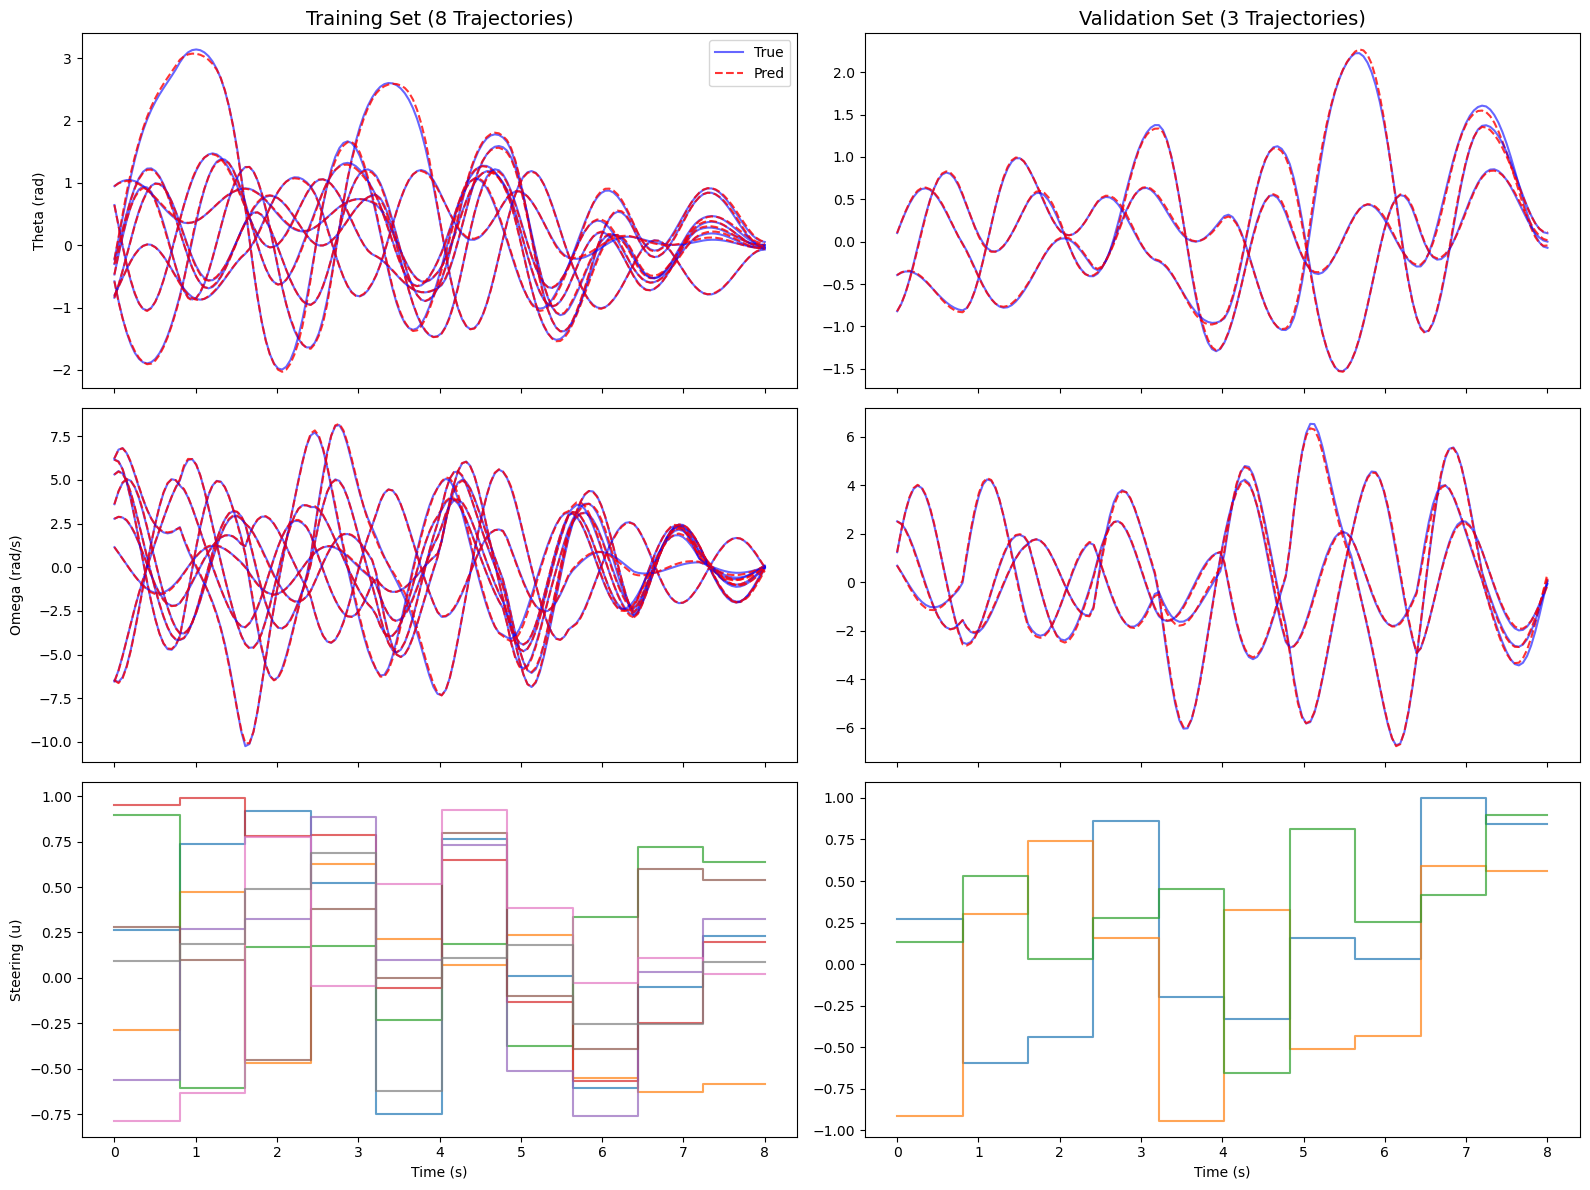

In [9]:
import matplotlib.pyplot as plt

with torch.no_grad():
    ode_func.set_u_func(u_func)
    pred_train = model(y_0s, ts).cpu().numpy()
    ode_func.set_u_func(u_func_val)
    pred_val = model(y_0s_val, ts).cpu().numpy()

true_train = trajectories.cpu().numpy()
true_val = trajectories_val.cpu().numpy()
t_np = ts.cpu().numpy()

fig, axs = plt.subplots(3, 2, figsize=(16, 12), sharex='col')

axs[0, 0].set_title("Training Set (8 Trajectories)", fontsize=14)
axs[0, 1].set_title("Validation Set (3 Trajectories)", fontsize=14)

def plot_column(col_idx, true_data, pred_data, steering_table_data):
    num_trajs = true_data.shape[1]
    for i in range(num_trajs):
        axs[0, col_idx].plot(t_np, true_data[:, i, 0], 'b', alpha=0.6, label='True' if i==0 else "")
        axs[0, col_idx].plot(t_np, pred_data[:, i, 0], 'r--', alpha=0.8, label='Pred' if i==0 else "")
        axs[1, col_idx].plot(t_np, true_data[:, i, 1], 'b', alpha=0.6)
        axs[1, col_idx].plot(t_np, pred_data[:, i, 1], 'r--', alpha=0.8)
        axs[2, col_idx].step(t_np, steering_table_data[:, i, 0].cpu().numpy(), where='post', alpha=0.7)

plot_column(0, true_train, pred_train, steering_table)
plot_column(1, true_val, pred_val, steering_table_val)


axs[0, 0].set_ylabel("Theta (rad)")
axs[1, 0].set_ylabel("Omega (rad/s)")
axs[2, 0].set_ylabel("Steering (u)")
axs[2, 0].set_xlabel("Time (s)")
axs[2, 1].set_xlabel("Time (s)")
axs[0, 0].legend()

plt.tight_layout()
plt.show()

## Test with other steering types

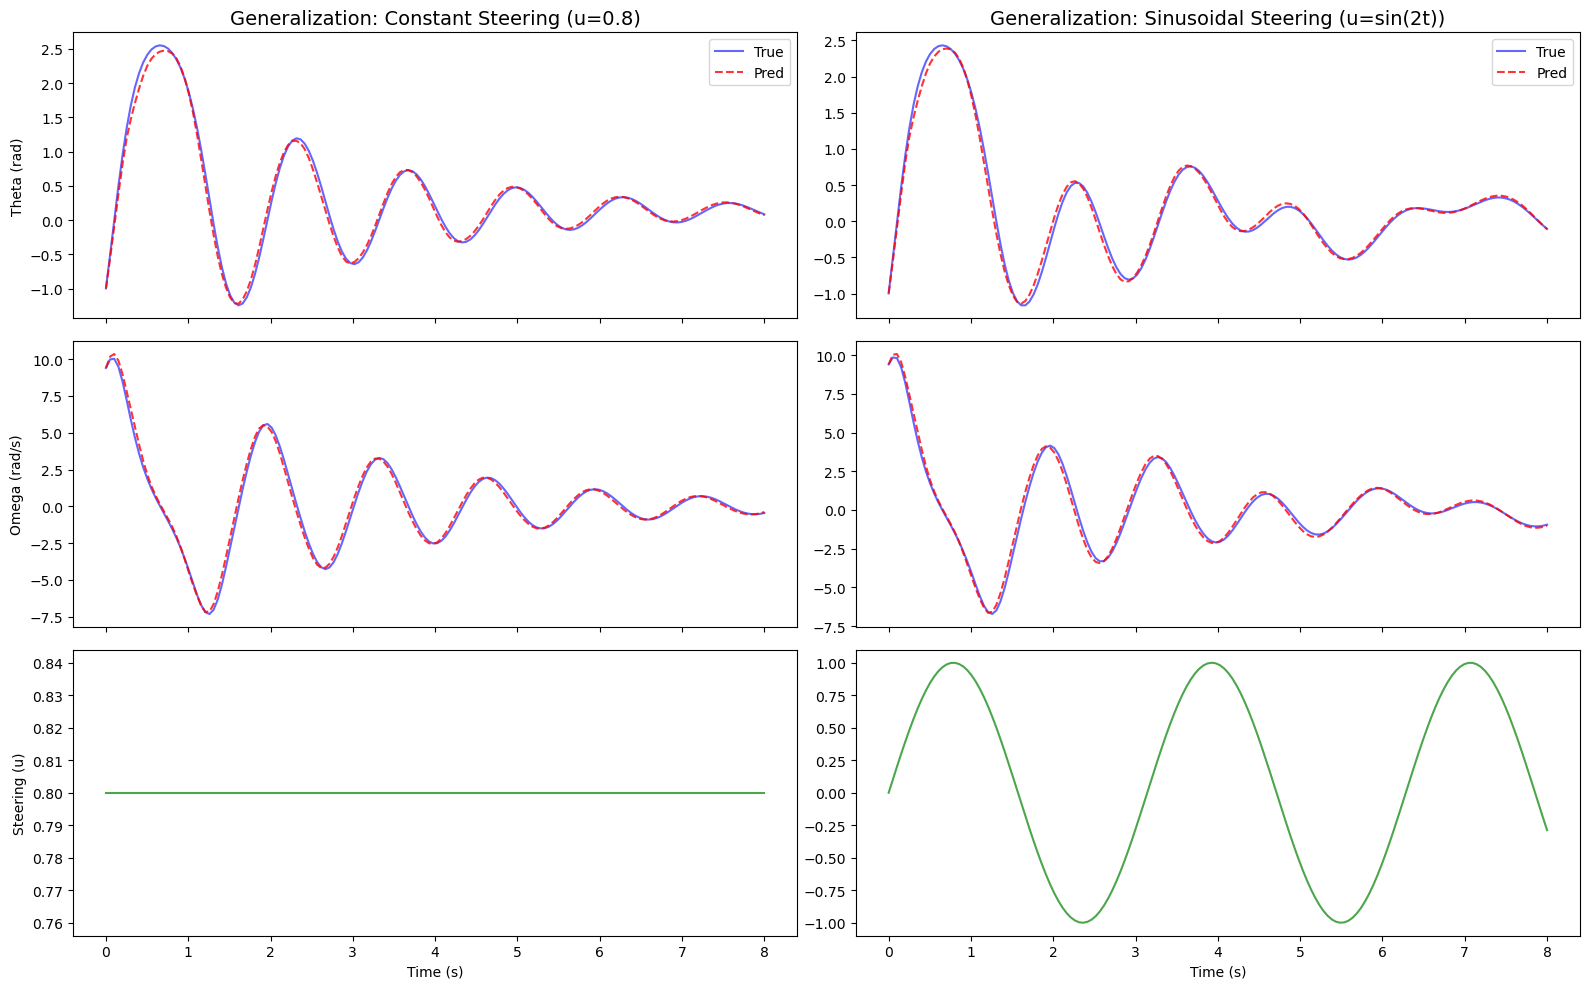

In [19]:
torch.manual_seed(99)
y_0_test = torch.rand((1, 2)).to(device)
y_0_test[:, 0] -= 1/2
y_0_test[:, 0] *= max_theta0
y_0_test[:, 1] -= 1/2
y_0_test[:, 1] *= 20

u_func_const = lambda t: torch.ones((1, 1)).to(device) * 0.2

pendulum_const = lambda t, state: pendulum_dynamics_without_u(t, state, u_func=u_func_const)
true_const_traj = odeint(pendulum_const, y_0_test, ts)

with torch.no_grad():
    ode_func.set_u_func(u_func_const)
    pred_const_traj = model(y_0_test, ts)

u_func_sin = lambda t: 0.4*torch.sin(2 * t) * torch.ones((1, 1)).to(device)

pendulum_sin = lambda t, state: pendulum_dynamics_without_u(t, state, u_func=u_func_sin)
true_sin_traj = odeint(pendulum_sin, y_0_test, ts)

with torch.no_grad():
    ode_func.set_u_func(u_func_sin)
    pred_sin_traj = model(y_0_test, ts)


fig, axs = plt.subplots(3, 2, figsize=(16, 10), sharex='col')

axs[0, 0].set_title("Generalization: Constant Steering (u=0.8)", fontsize=14)
axs[0, 1].set_title("Generalization: Sinusoidal Steering (u=sin(2t))", fontsize=14)

t_np = ts.cpu().numpy()

true_const = true_const_traj.cpu().numpy()[:, 0, :]
pred_const = pred_const_traj.cpu().numpy()[:, 0, :]
u_const_vals = [0.8 for _ in t_np]

true_sin = true_sin_traj.cpu().numpy()[:, 0, :]
pred_sin = pred_sin_traj.cpu().numpy()[:, 0, :]
u_sin_vals = [torch.sin(torch.tensor(2 * t)).item() for t in t_np]

axs[0, 0].plot(t_np, true_const[:, 0], 'b', alpha=0.6, label='True')
axs[0, 0].plot(t_np, pred_const[:, 0], 'r--', alpha=0.8, label='Pred')
axs[1, 0].plot(t_np, true_const[:, 1], 'b', alpha=0.6)
axs[1, 0].plot(t_np, pred_const[:, 1], 'r--', alpha=0.8)
axs[2, 0].plot(t_np, u_const_vals, 'g', alpha=0.7)

axs[0, 1].plot(t_np, true_sin[:, 0], 'b', alpha=0.6, label='True')
axs[0, 1].plot(t_np, pred_sin[:, 0], 'r--', alpha=0.8, label='Pred')
axs[1, 1].plot(t_np, true_sin[:, 1], 'b', alpha=0.6)
axs[1, 1].plot(t_np, pred_sin[:, 1], 'r--', alpha=0.8)
axs[2, 1].plot(t_np, u_sin_vals, 'g', alpha=0.7)

axs[0, 0].set_ylabel("Theta (rad)")
axs[1, 0].set_ylabel("Omega (rad/s)")
axs[2, 0].set_ylabel("Steering (u)")
axs[2, 0].set_xlabel("Time (s)")
axs[2, 1].set_xlabel("Time (s)")

axs[0, 0].legend()
axs[0, 1].legend()

plt.tight_layout()
plt.show()

## Unstable steering

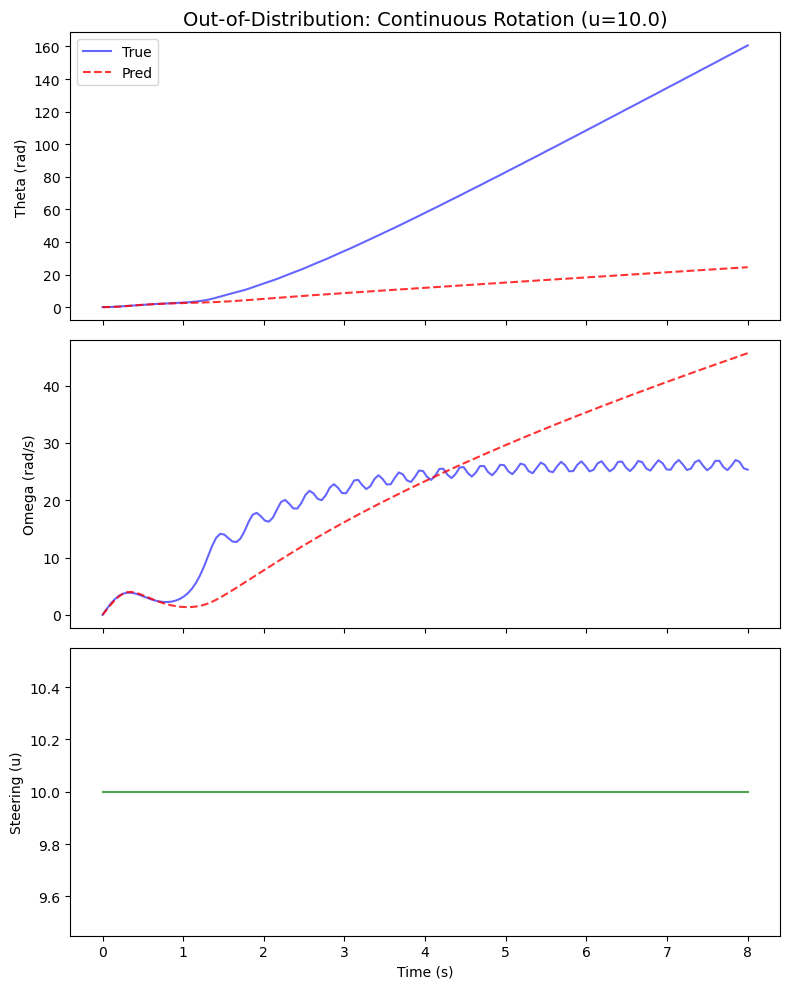

In [24]:
torch.manual_seed(101)
y_0_spin = torch.zeros((1, 2)).to(device)

u_func_spin = lambda t: torch.ones((1, 1)).to(device) * 1.4

pendulum_spin = lambda t, state: pendulum_dynamics_without_u(t, state, u_func=u_func_spin)
true_spin_traj = odeint(pendulum_spin, y_0_spin, ts)

with torch.no_grad():
    ode_func.set_u_func(u_func_spin)
    pred_spin_traj = model(y_0_spin, ts)

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axs[0].set_title("Out-of-Distribution: Continuous Rotation (u=10.0)", fontsize=14)

t_np = ts.cpu().numpy()
true_spin = true_spin_traj.cpu().numpy()[:, 0, :]
pred_spin = pred_spin_traj.cpu().numpy()[:, 0, :]
u_spin_vals = [10.0 for _ in t_np]

axs[0].plot(t_np, true_spin[:, 0], 'b', alpha=0.6, label='True')
axs[0].plot(t_np, pred_spin[:, 0], 'r--', alpha=0.8, label='Pred')
axs[0].set_ylabel("Theta (rad)")
axs[0].legend()

axs[1].plot(t_np, true_spin[:, 1], 'b', alpha=0.6)
axs[1].plot(t_np, pred_spin[:, 1], 'r--', alpha=0.8)
axs[1].set_ylabel("Omega (rad/s)")

axs[2].plot(t_np, u_spin_vals, 'g', alpha=0.7)
axs[2].set_ylabel("Steering (u)")
axs[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()